On a un pb de régression

modèles à essayer : régression linéaire, KNN, forets aléatoires, xgboost, réseaux de neuronnes
(notamment des RNN car séries temporelles)

mélangent de modèles ? 


QUESTIONNEMENT : 

- prédire les deux sorties à la fois ou les deux séparément ?
La question se pose surtout
pour les réseaux de neuronnes : des études ont montré que dans certains cas (je me rappelle plus lesquels)
cela améliore la performance car cela oblige le réseau de neuronnes à comprendre dans la profondeur les
données

- Quel retard choisir ?? 
Peut être choisir par validation croisée ? 

- peu de données ... 1000 observations --> attention au surapprentissage 








On importe les modules et packages nécessaires pour le on fonctionnement du code (peut être faire un 
requirements.txt puis pip install -r requirements.txt)

In [120]:
#%pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

chargement des données et première exploration des données

['Utr', 'Ytr', 'Uts1', 'Uts2']
Utr shape: (1000, 2)
Ytr shape: (1000, 2)
Uts shape: (1000, 2)
Uts2 shape: (1000, 2)
       Utr0      Utr1
0  1.225856  0.043213
1 -0.379083 -0.411898
2  0.683140 -0.921644
3  0.374853 -0.572683
4  0.256665 -0.760764
       Ytr0      Ytr1
0  0.000000  0.000000
1  0.042170  0.720120
2 -0.016521 -0.222306
3 -0.235810  0.020866
4 -0.080339 -0.352666


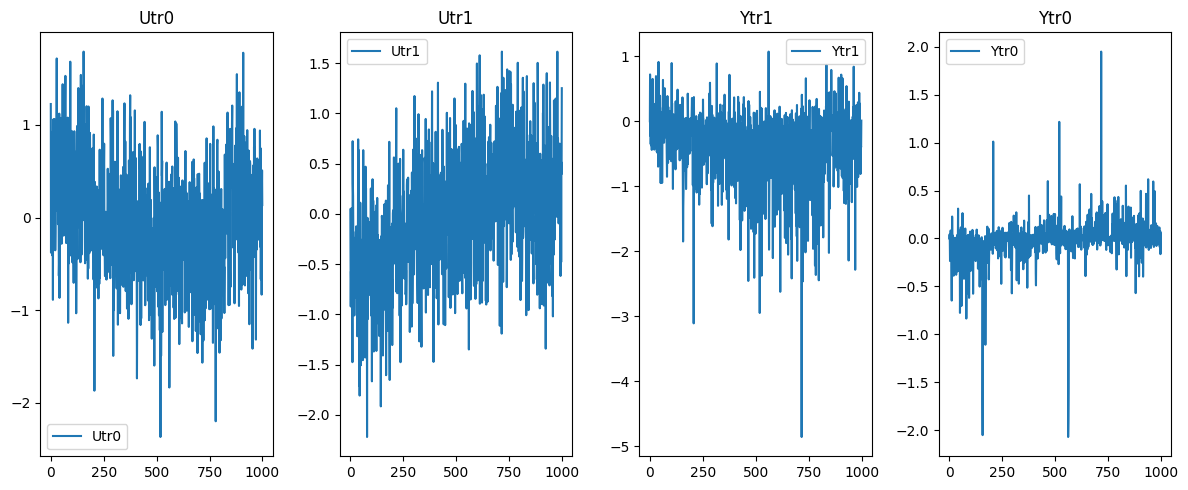

In [121]:
# Charger le fichier
data = np.load('StudentdataNARX.npz')

# Voir la liste des variables
print(data.files)


Utr = data['Utr']
Ytr = data['Ytr']
Uts = data['Uts1']
Uts2 = data['Uts2']

print("Utr shape:", Utr.shape)
print("Ytr shape:", Ytr.shape)
print("Uts shape:", Uts.shape)
print("Uts2 shape:", Uts2.shape)



# transformer les données de train en dataframe pandas
X = pd.DataFrame(Utr, columns=[f'Utr{i}' for i in range(Utr.shape[1])])
Y = pd.DataFrame(Ytr, columns=[f'Ytr{i}' for i in range(Ytr.shape[1])])
print(X.head(5))
print(Y.head(5))



figure, axes = plt.subplots(1, 4, figsize=(12, 5))
axes[0].plot(X['Utr0'], label='Utr0')
axes[0].set_title('Utr0')
axes[0].legend()
axes[1].plot(X['Utr1'], label='Utr1')
axes[1].set_title('Utr1')
axes[1].legend()
axes[2].plot(Y['Ytr1'], label='Ytr1')
axes[2].set_title('Ytr1')
axes[2].legend()
axes[3].plot(Y['Ytr0'], label='Ytr0')
axes[3].set_title('Ytr0')
axes[3].legend()
plt.tight_layout()
plt.show()


- Création des pilotes

PILOTE NARX1

          u
0  0.000000
1  0.000000
2  1.295377
3  3.046060
4 -0.468307
shape U (1001, 1)
         y1        y2
0  0.000000  0.000000
1  0.462317  0.029815
2 -0.293658  1.054210
3  1.469774  0.998512
4  2.599175  1.279188
5  1.048929  1.816137
6  1.567966  3.835793
7  0.871232  2.699416
8  2.905220  1.035607
9  1.686253  0.726644
shape Y (1000, 2)
shape U (1000, 1)


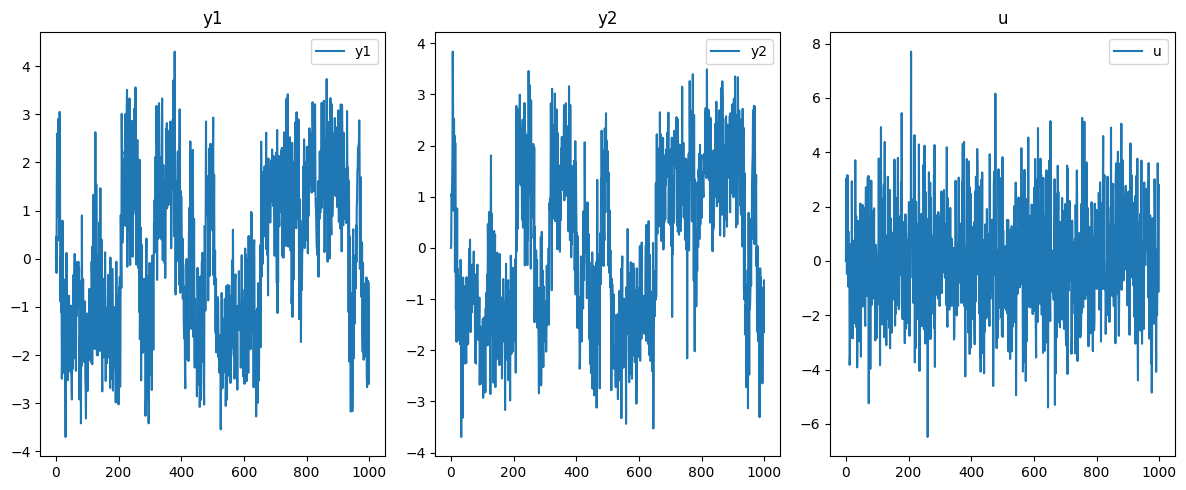

In [ ]:
np.random.seed(42) # pour la reproductibilité

n_points = 1000
# création des pilotes donnés dans l'énoncé

# génération de U
U_Narx1_train = pd.DataFrame(columns=['u'])
Y_Narx1_train = pd.DataFrame(columns=['y1', 'y2'])
# générer U qui suit une distribution normale (moyenne 0, écart-type 2) : mon choix
# arbitraire
U_Narx1_train['u'] = np.random.normal(0, 2, size=n_points+1)
# n+1 points car on a u-1 qui doit être défini pour générer y1_1 et y2_1 :
# on change sa valeur en 0 après
U_Narx1_train.loc[0, 'u'] = 0 # pour respecter l'énoncé =u-1 = 0
U_Narx1_train.loc[1, 'u'] = 0 # u0 = 0

print(U_Narx1_train.head())
print("shape U", U_Narx1_train.shape)


# génération de Y
# y1_0 = 0, y2_0 = 0 # cf énoncé : je me mets dans le m^me cas que les données réelles
# à prédire (exo principal du projet)
y1_0 = 0
y2_0 = 0
# y-1 = 0, y-2 = 0 # cf énoncé, nécessaire pour générer y1_1 et y2_1
y1_minus_1 = 0
y2_minus_1 = 0
Y_Narx1_train.loc[0] = [y1_minus_1, y2_minus_1]
Y_Narx1_train.loc[1] = [y1_0, y2_0]

for i in range(2, n_points+1): # on est décalé à 2 car on a ajouter y-1
    # les indices seront réglés après la boucle
    # deux formules données dans l'énoncé
    y1_i = 0.5 * Y_Narx1_train['y2'].iloc[i-2] + np.sin(Y_Narx1_train['y2'].iloc[i-1]) + 0.3 * U_Narx1_train['u'].iloc[i-2] + np.random.normal(loc=0, scale=0.5)
    y2_i = 0.5 * Y_Narx1_train['y1'].iloc[i-2] + np.sin(Y_Narx1_train['y1'].iloc[i-1]) + 0.2 * U_Narx1_train['u'].iloc[i-1] + np.random.normal(loc=0, scale=0.5)
    Y_Narx1_train.loc[i] = [y1_i, y2_i]

# enlever la première ligne qui correspond à y-1 et u-1et qui ont servi à générer les données
Y_Narx1_train = Y_Narx1_train.drop(index=0).reset_index(drop=True)
U_Narx1_train = U_Narx1_train.drop(index=0).reset_index(drop=True)

print(Y_Narx1_train.head(10))
print("shape Y", Y_Narx1_train.shape)
print("shape U", U_Narx1_train.shape)


# visualiser les données générées
figure, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].plot(Y_Narx1_train['y1'], label='y1')
axes[0].set_title('y1')
axes[0].legend()
axes[1].plot(Y_Narx1_train['y2'], label='y2')
axes[1].set_title('y2')
axes[1].legend()
axes[2].plot(U_Narx1_train['u'], label='u')
axes[2].set_title('u')
axes[2].legend()
plt.tight_layout()
plt.show()


PILOTE NARX2

         u1        u2
0  0.000000  0.000000
1  0.000000  0.000000
2  0.064769 -0.064694
3  0.152303  0.069822
4 -0.023415  0.039349
shape U (1001, 2)
               y1        y2
0    0.000000e+00  0.000000
1   -4.026793e+00  0.061689
2   -9.398251e+00  0.154436
3    4.522674e-02 -0.009531
4    3.053901e+00  0.009154
5   -6.795720e+00 -0.005859
6   -3.683863e+00 -0.001969
7    2.057268e+01 -0.002769
8    2.136982e+02 -0.019146
9    9.996526e+03 -0.012498
10   1.699084e+07  0.002773
11   1.601307e+15 -0.013088
12  -1.873314e+29  0.001838
13  -1.503065e+58  0.012389
14  1.428667e+116 -0.004916
shape Y (1000, 2)
shape U (1000, 2)


/var/folders/qv/9bg0yhfn5p55gc_h564k02y40000gn/T/ipykernel_7900/4121620730.py:63: RuntimeWarning: overflow encountered in scalar multiply
  num1 = y1_k * y1_km1 * y1_km2 * (y1_km2 - 1) * u2_km1 + u2_k
/var/folders/qv/9bg0yhfn5p55gc_h564k02y40000gn/T/ipykernel_7900/4121620730.py:69: RuntimeWarning: overflow encountered in scalar power
  den2 = 1 + y1_km1**2 + y1_km2**2
/var/folders/qv/9bg0yhfn5p55gc_h564k02y40000gn/T/ipykernel_7900/4121620730.py:69: RuntimeWarning: overflow encountered in scalar power
  den2 = 1 + y1_km1**2 + y1_km2**2


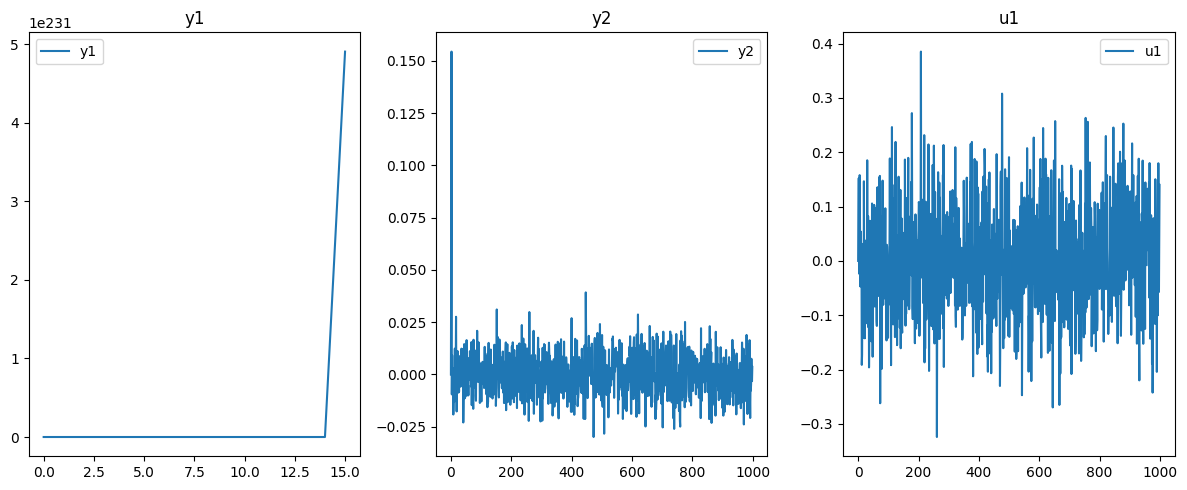

In [ ]:
np.random.seed(42) # pour la reproductibilité

# génération de U (deux colonnes cette fois ci u1 et u2)
U_Narx1_train = pd.DataFrame(columns=['u1', 'u2'])
Y_Narx1_train = pd.DataFrame(columns=['y1', 'y2'])
# générer U qui suit une distribution normale (moyenne 0, écart-type 0.1) : mon choix
# arbitraire. Pour le coupp si je mets une trop grand evariance il y a explosion des données
U_Narx1_train['u1'] = np.random.normal(0, 0.1, size=n_points+1)
U_Narx1_train['u2'] = np.random.normal(0, 0.1, size=n_points+1)
# n+1 points car on a u-1 qui doit être défini pour générer y1_1 et y2_1 :
# on change sa valeur en 0 après
# pa rapport à la génération de Y, pas besoin de remonter à u-2 (cf formules)
U_Narx1_train.loc[0, 'u1'] = 0 # pour respecter l'énoncé =u-1 = 0
U_Narx1_train.loc[1, 'u1'] = 0 # u0 = 0
U_Narx1_train.loc[0, 'u2'] = 0 # pour respecter l'énoncé =u-1 = 0
U_Narx1_train.loc[1, 'u2'] = 0 # u0 = 0

print(U_Narx1_train.head())
print("shape U", U_Narx1_train.shape)


# génération de Y
# y1_0 = 0, y2_0 = 0 # cf énoncé : je me mets dans le m^me cas que les données réelles
# à prédire (exo principal du projet)
y1_0 = 0
y2_0 = 0
# y-1 = 0, y-2 = 0 # cf énoncé, nécessaire pour générer y1_1 et y2_1
y1_minus_1 = 0
y2_minus_1 = 0
y1_minus_2 = 0
y2_minus_2 = 0
Y_Narx1_train.loc[0] = [y1_minus_2, y2_minus_2]
Y_Narx1_train.loc[1] = [y1_minus_1, y2_minus_1]
Y_Narx1_train.loc[2] = [y1_0, y2_0]
# Bien faire attention à supprimer les 2 lignes à la fin et pas une seule
# il faudra peut être les rajouter pour nos stratégies dans le futur (dépend de à quel point on souhaite
# regarder le futur)


for k in range(2, n_points+1): # on est décalé à 2 car on a ajouter y-1
    # les indices seront réglés après la boucle
    # deux formules données dans l'énoncé

    y1_k = Y_Narx1_train.loc[k, 'y1']
    y1_km1 = Y_Narx1_train.loc[k-1, 'y1']
    y1_km2 = Y_Narx1_train.loc[k-2, 'y1']

    y2_k = Y_Narx1_train.loc[k, 'y2']
    y2_km1 = Y_Narx1_train.loc[k-1, 'y2']
    y2_km2 = Y_Narx1_train.loc[k-2, 'y2']

    u1_k = U_Narx1_train.loc[k, 'u1']
    u1_km1 = U_Narx1_train.loc[k-1, 'u1']

    u2_k = U_Narx1_train.loc[k, 'u2']
    u2_km1 = U_Narx1_train.loc[k-1, 'u2']

    # Génération du bruit blanc w
    w1 = np.random.normal(0, 0.02)
    w2 = np.random.normal(0, 0.02)

    # Formule pour y1(k+1)
    num1 = y1_k * y1_km1 * y1_km2 * (y1_km2 - 1) * u2_km1 + u2_k
    den1 = 1 + y2_km1**2 + y2_km2**2
    y1_plus1 = (num1 / den1) + w1

    # Formule pour y2(k+1)
    num2 = y2_k * y2_km1 * y2_km2 * (y2_km2 - 1) * u1_km1 + u1_k
    den2 = 1 + y1_km1**2 + y1_km2**2
    y2_plus1 = (num2 / den2) + w2

    # Stockage du résultat à l'indice k+1
    Y_Narx1_train.loc[k+1] = [y1_plus1, y2_plus1]

# enlever la première ligne qui correspond à y-1 et u-1et qui ont servi à générer les données
Y_Narx1_train = Y_Narx1_train.drop(index=1).reset_index(drop=True)
Y_Narx1_train = Y_Narx1_train.drop(index=0).reset_index(drop=True)
U_Narx1_train = U_Narx1_train.drop(index=0).reset_index(drop=True)

print(Y_Narx1_train.head(15))
print("shape Y", Y_Narx1_train.shape)
print("shape U", U_Narx1_train.shape)

# visualiser les données générées
figure, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].plot(Y_Narx1_train['y1'], label='y1')
axes[0].set_title('y1')
axes[0].legend()
axes[1].plot(Y_Narx1_train['y2'], label='y2')
axes[1].set_title('y2')
axes[1].legend()
axes[2].plot(U_Narx1_train['u1'], label='u1')
axes[2].set_title('u1')
axes[2].legend()
plt.tight_layout()
plt.show()


On a des données très très bruitées .... Utiliser des pilotes très bruités

- Analyse en vif, très vif sur les vrais données

In [389]:
# calculer la corrélation entre les différentes variables
df_total = pd.concat([X], axis=1)
correlation_matrix_total = df_total.corr()
print("Correlation matrix:\n", correlation_matrix_total)

Correlation matrix:
                Utr0      Utr1  Utr0_lag1  Utr1_lag1  Ytr0_lag1  Ytr1_lag1  \
Utr0       1.000000 -0.097714   0.193971  -0.074416  -0.055324   0.059056   
Utr1      -0.097714  1.000000  -0.051110   0.202018   0.038429  -0.051170   
Utr0_lag1  0.193971 -0.051110   1.000000  -0.105371  -0.050098   0.108617   
Utr1_lag1 -0.074416  0.202018  -0.105371   1.000000   0.109876  -0.103601   
Ytr0_lag1 -0.055324  0.038429  -0.050098   0.109876   1.000000  -0.249875   
Ytr1_lag1  0.059056 -0.051170   0.108617  -0.103601  -0.249875   1.000000   
Utr0_lag2  0.159237 -0.101353   0.197681  -0.056884  -0.181153   0.655565   
Utr1_lag2 -0.061731  0.084080  -0.083412   0.205671   0.418404  -0.413031   
Ytr0_lag2 -0.090282  0.069470  -0.062042   0.042475   0.436033   0.249054   
Ytr1_lag2  0.086269 -0.043512   0.063577  -0.054254  -0.014755  -0.164196   
Utr0_lag3  0.148375 -0.099207   0.166983  -0.108325  -0.064805  -0.071404   
Utr1_lag3 -0.092783  0.080518  -0.064818   0.084064   0

Les coefficients ne sont pas si élevés que ca ... la régression linéaire sur ces variables explicatives semblent compromis

- REGRESSION LINEAIRE 

On va d'abord faire une régression linéaire en utilisant simplement les valeurs de u1 et u2 pour prédire y. On s'attend cependant à des résultats plutôt moyen 

Mean Squared Error: 0.015914528988035775
Coefficients: [ 0.01087287  0.00837739 -0.05401612  0.14741551  0.47594334  0.04315679
 -0.00529679 -0.04866907  0.00314159  0.00056876 -0.00086697  0.00595226
 -0.03004756 -0.00113145]
Intercept: 0.006246303527356188
Mean Prediction MSE: 0.019263029098510742


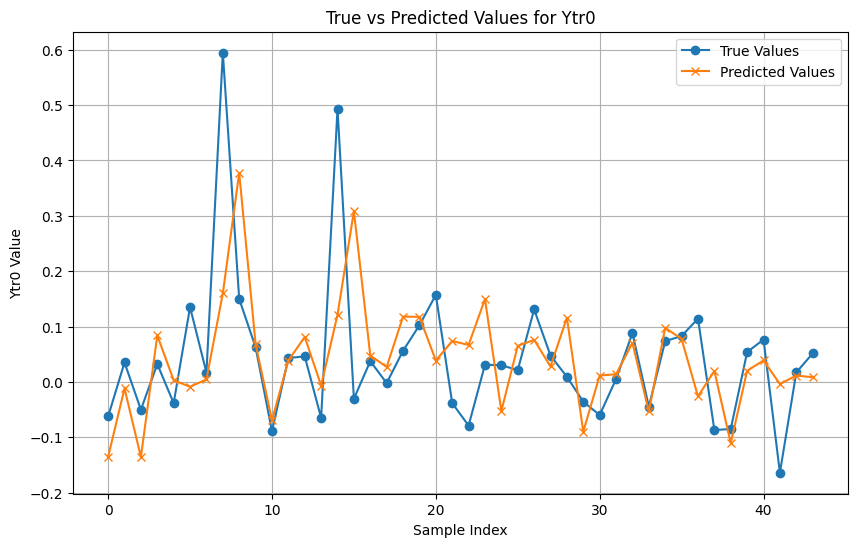

In [390]:
X_val = X[800:1000]
Y_val = Y[800:1000]
X_train = X[:800]
Y_train = Y[:800]

model = LinearRegression()
model.fit(X_train, Y_train["Ytr0"])
Y_pred = model.predict(X_val)
mse = mean_squared_error(Y_val["Ytr0"], Y_pred)
print("Mean Squared Error:", mse)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# erreur si on prédit la valeur moyenne de Ytr0
mean_prediction = np.mean(Y_train["Ytr0"])
mean_mse = mean_squared_error(Y_val["Ytr0"], [mean_prediction] * len(Y_val))
print("Mean Prediction MSE:", mean_mse)


# affichage des résultats
plt.figure(figsize=(10, 6))
plt.plot(Y_val["Ytr0"].values, label='True Values', marker='o')
plt.plot(Y_pred, label='Predicted Values', marker='x')
plt.title('True vs Predicted Values for Ytr0')
plt.xlabel('Sample Index')
plt.ylabel('Ytr0 Value')
plt.legend()
plt.grid()
plt.show()

On voit bien en comparant le mse d'un modèle qui prédit la moyenne de Ytr0 que le modèle 
de régression linéaire uniquement sur l'instant t

In [391]:
X["Utr0_lag1"] = X["Utr0"].shift(1)
X["Utr1_lag1"] = X["Utr1"].shift(1)
X["Ytr0_lag1"] = Y["Ytr0"].shift(1)
X["Ytr1_lag1"] = Y["Ytr1"].shift(1)
X["Utr0_lag2"] = X["Utr0"].shift(2)
X["Utr1_lag2"] = X["Utr1"].shift(2)
X["Ytr0_lag2"] = Y["Ytr0"].shift(2)
X["Ytr1_lag2"] = Y["Ytr1"].shift(2)
X["Utr0_lag3"] = X["Utr0"].shift(3)
X["Utr1_lag3"] = X["Utr1"].shift(3)
X["Ytr0_lag3"] = Y["Ytr0"].shift(3)
X["Ytr1_lag3"] = Y["Ytr1"].shift(3)
X = X.dropna()
Y = Y.loc[X.index] # le dropna a supprimé les 3 premières lignes et n'a pas modifié les index
X_val = X[800:1000]
Y_val = Y[800:1000]
X_train = X[:800]
Y_train = Y[:800]
model = LinearRegression()
model.fit(X_train, Y_train["Ytr0"])
Y_pred = model.predict(X_val)
mse = mean_squared_error(Y_val["Ytr0"], Y_pred)
print("Mean Squared Error with lags:", mse)


Mean Squared Error with lags: 0.0155116847634466


Le problème c'est que là je connais le futur donc j'utilise les données réelles pour yk-1, etc et non les données prédites ... Cela evite l'effet boule de neige mais ce ne sera pas le cas en vrai ...

In [392]:
# utiliser sa propre prédiction comme entrée pour les prédictions futures
Y_pred_future = []
current_input = X_val.iloc[0].copy() # copy pour ne pas modifier X_val
for i in range(len(X_val)):
    pred = model.predict(current_input.values.reshape(1, -1))[0]
    Y_pred_future.append(pred)
    current_input["Ytr0_lag1"] = pred
    current_input["Ytr0_lag2"] = current_input["Ytr0_lag1"]
    current_input["Ytr0_lag3"] = current_input["Ytr0_lag2"]
    current_input["Utr0_lag1"] = current_input["Utr0"]
    current_input["Utr1_lag1"] = current_input["Utr1"]
    current_input["Utr0_lag2"] = current_input["Utr0_lag1"]
    current_input["Utr1_lag2"] = current_input["Utr1_lag1"]
    current_input["Utr0_lag3"] = current_input["Utr0_lag2"]
    current_input["Utr1_lag3"] = current_input["Utr1_lag2"]
mse_future = mean_squared_error(Y_val["Ytr0"], Y_pred_future)
print("Mean Squared Error with future predictions:", mse_future)

Mean Squared Error with future predictions: 0.022404052317142487


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-p